In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.anova import AnovaRM
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set seaborn style for better aesthetics
sns.set(style="whitegrid")

# Load the dataset
file_path = 'main_data_filled.csv'

try:
    df = pd.read_csv(file_path)
    
    # --- 1. Prepare Data for Analysis ---
    # Convert categorical variables to 'category' type
    # This ensures statsmodels and seaborn treat them as factors
    df['Block'] = df['Block'].astype('category')
    df['conflict'] = df['conflict'].astype('category')
    df['caseid'] = df['caseid'].astype('category')
    
    # --- 2. Aggregate Data for RM-ANOVA ---
    # We calculate the mean 'correct' score (accuracy)
    # for each subject in each of the 2x2 conditions.
    print("Aggregating data: calculating mean 'correct' for each subject per condition...")
    agg_df = df.groupby(['caseid', 'Block', 'conflict'])['correct'].mean().reset_index()
    
    print("--- Aggregated Data (Head) ---")
    print(agg_df.head())
    
    # Check if aggregation was successful
    if agg_df.empty:
        print("Error: Aggregated DataFrame is empty. Check input data.")
    else:
        # --- 3. Perform 2x2 Repeated Measures ANOVA ---
        print("\n--- Running Repeated Measures ANOVA ---")
        
        # Ensure there are no NaN values in the aggregated data for the ANOVA
        agg_df_clean = agg_df.dropna(subset=['correct', 'caseid', 'Block', 'conflict'])
            
        aov = AnovaRM(
            data=agg_df_clean,
            depvar='correct',
            subject='caseid',
            within=['Block', 'conflict']
        )
        res = aov.fit()
        
        print("\n--- ANOVA Results ---")
        print(res.summary())
    
except FileNotFoundError:
    print(f"Error: The file {file_path} was not found.")
except Exception as e:
    print(f"An error occurred during analysis or plotting: {e}")

Aggregating data: calculating mean 'correct' for each subject per condition...
--- Aggregated Data (Head) ---
  caseid Block conflict   correct
0      1     3        0  0.944444
1      1     3        1  0.866667
2      1     6        0  0.750000
3      1     6        1  0.731579
4      2     3        0  0.896825

--- Running Repeated Measures ANOVA ---

--- ANOVA Results ---
                   Anova
               F Value Num DF  Den DF Pr > F
--------------------------------------------
Block          21.6021 1.0000 35.0000 0.0000
conflict       21.8818 1.0000 35.0000 0.0000
Block:conflict 71.0269 1.0000 35.0000 0.0000



Aggregating data...
--- Data prepared for plotting (Head) ---
  caseid Block conflict   correct Block_as_String        Conflict Condition
0      1     3        0  0.944444               3    Congruent (Conflict=0)
1      1     3        1  0.866667               3  Incongruent (Conflict=1)
2      1     6        0  0.750000               6    Congruent (Conflict=0)
3      1     6        1  0.731579               6  Incongruent (Conflict=1)
4      2     3        0  0.896825               3    Congruent (Conflict=0)

--- Generating Modified Interaction Plot ---

Modified interaction plot successfully saved as: interaction_plot_wm_conflict_v2.png


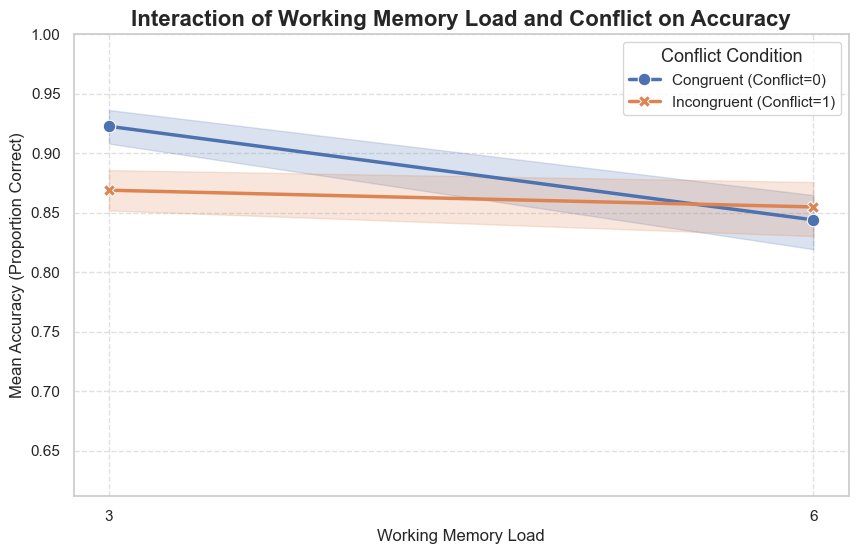

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set seaborn style for better aesthetics
sns.set(style="whitegrid")

# Load the dataset
file_path = 'main_data_filled.csv'

try:
    df = pd.read_csv(file_path)
    
    # --- 1. Prepare Data ---
    # Convert categorical variables to 'category' type
    df['Block'] = df['Block'].astype('category')
    df['conflict'] = df['conflict'].astype('category')
    df['caseid'] = df['caseid'].astype('category')
    
    # --- 2. Aggregate Data ---
    # Calculate mean 'correct' for each subject per condition
    print("Aggregating data...")
    agg_df = df.groupby(['caseid', 'Block', 'conflict'])['correct'].mean().reset_index()
    
    # Drop any potential NaN rows that could interfere with plotting
    agg_df_clean = agg_df.dropna(subset=['correct', 'caseid', 'Block', 'conflict'])

    # --- 3. Modify Data Specifically for Plotting ---
    # To ensure the x-axis *only* shows '3' and '6' as discrete labels,
    # we convert the 'Block' column to a string type for the plot.
    agg_df_clean['Block_as_String'] = agg_df_clean['Block'].astype(str)
    
    # We also create the mapping for the legend
    agg_df_clean['Conflict Condition'] = agg_df_clean['conflict'].map({0: 'Congruent (Conflict=0)', 1: 'Incongruent (Conflict=1)'})

    print("--- Data prepared for plotting (Head) ---")
    print(agg_df_clean.head())

    # --- 4. Create Interaction Plot (Modified) ---
    print("\n--- Generating Modified Interaction Plot ---")
    
    plt.figure(figsize=(10, 6))
    
    # Use the new 'Block_as_String' column for the x-axis
    ax = sns.lineplot(
        data=agg_df_clean,
        x='Block_as_String',  # Use the string column here
        y='correct',
        hue='Conflict Condition',
        style='Conflict Condition',
        markers=True,
        dashes=False,
        markersize=9,
        linewidth=2.5,
        errorbar=('ci', 95) # 95% Confidence Interval
    )
    
    # --- Customize Plot (in English) ---
    ax.set_title('Interaction of Working Memory Load and Conflict on Accuracy', fontsize=16, fontweight='bold')
    
    # Set the x-axis label. The ticks will automatically be '3' and '6'.
    ax.set_xlabel("Working Memory Load", fontsize=12)
    ax.set_ylabel('Mean Accuracy (Proportion Correct)', fontsize=12)
    
    # Improve legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=labels, title='Conflict Condition', title_fontsize='13', fontsize='11', loc='best')
    
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Set y-axis limits
    min_accuracy = agg_df_clean['correct'].min()
    ax.set_ylim(max(0, min_accuracy - 0.05), 1.0)
    
    # Save the plot with a new name
    plot_filename = 'interaction_plot_wm_conflict_v2.png'
    plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
    print(f"\nModified interaction plot successfully saved as: {plot_filename}")

except FileNotFoundError:
    print(f"Error: The file {file_path} was not found.")
except Exception as e:
    print(f"An error occurred during analysis or plotting: {e}")